In [1]:
import pandas as pd
from VSP_Auxiliary import *
from astropy.table import Table
from matplotlib import pyplot as plt
from pyasassn.client import SkyPatrolClient
#%matplotlib agg

client = SkyPatrolClient()

Welcome to ASAS-SN Skypatrol!

Current Deployment Version: 0.6.17 (26 JAN 2024)
Please upgrade your client if not up to date.



In [2]:
def download(coord, save_dir, save_name, radius = 2/3600):
    if radius > 60/3600:
        raise ValueError('query radius should be smaller than 60 arcsec.')
    # 输入：坐标和保存目录, radius单位是度
    # 函数使用SQL语句查询，将csv光变曲线下载至保存路径
    # 返回下载后的光变曲线文件列表
    ra = coord.ra.value
    dec = coord.dec.value
    query = f"""
    SELECT 
     * 
    FROM stellar_main 
    WHERE DISTANCE(ra_deg, dec_deg, {ra}, {dec}) <= {radius}
    """
    lcs = client.adql_query(query, download=True, save_dir=save_dir, file_format="csv", threads=2)
    for i in range(len(lcs)):
        if i == 0:
            os.rename(lcs[i], save_dir+save_name)
            print('ASASSN lc has been saved to',save_dir+save_name)
        else:
            os.remove(lcs[i])
            print('ASASSN lc',lcs[i],'has been removed.')
    if os.path.exists(save_dir+'index.csv'):
        os.rename(save_dir+'index.csv', save_dir+'ASAS_query_index.csv')
    if len(lcs)==0:
        print('ASASSN lc not found.')
        return False
    else:
        return save_dir+save_name

# 测试
#c = SkyCoord('06 52 37.19 +24 36 22.1', unit=(u.hourangle, u.deg), frame='fk5')
#create_dir('./Temp/J065238_ASAS/')
#download(c,save_dir='./Temp/J065238_ASAS/',save_name='J065238_ASASSN_lc.csv',radius = 2/3600)

In [3]:
def read_lc(lc_name):
    # 输入download_asassn_lc()下载后的csv文件名称
    # 程序读取光变曲线数据和第一行源信息
    # 返回csv文件中原始的光变曲线数据data和header信息，但未经进一步处理
    data = pd.read_csv(lc_name, skiprows=[0]) # 跳过源信息，读取光变曲线数据  data的格式是pandas.core.frame.DataFrame
    with open(lc_name, encoding='utf-8') as f:
        csvfile = csv.reader(f)
        counter = 0
        for row in csvfile:
            counter += 1
            if counter > 0:
                break
        header = row
    return data, header
# 测试
#data, header = read_lc('./Temp/J065238_ASAS/J065238_ASASSN_lc.csv')
#data, header

In [4]:
def screen_data(lc_data):
    # 输入read_asassn_lc()返回的data
    # 函数筛选quality=G, mag<mag_limit, mag_err!=99.999(<0.5),并分成V和g波段
    # 返回V和g波段光变曲线数据
    
    # 筛选质量：quality==G, mag<mag_limit, mag_err!=99.999
    data1 = lc_data[lc_data['quality']=='G']
    data2 = data1[data1['mag']<data1['limit']]
    data3 = data2[data2['mag_err']<0.5]
    dataV = data3[data3['phot_filter']=='V']
    datag = data3[data3['phot_filter']=='g']
    return dataV, datag

def screen_header(lc_header):
    # 输入read_asassn_lc()返回的header
    # 输出字典
    dic = {}
    for item in lc_header:
        if item[0]=='#':
            item = item.split()[1]
            key = item.split(':')[0].split('"')[1]
            value = item.split(':')[1]
            dic[key] = value
        else:
            key = item.split(':')[0]
            value = item.split(':')[1]
            dic[key] = value
    return dic

# 测试
#screen_data(data),screen_header(header)

In [5]:
def output_data(lc_name):
    # 输入从download_asassn_lc()下载到的csv文件名称
    # 程序读取csv文件并筛选可用数据
    # 输出(V波段光变曲线， g波段光变曲线，头信息), 光变曲线格式为pandas DataFrame
    data, header = read_lc(lc_name)
    dataV, datag = screen_data(data)
    header = screen_header(header)
    return (dataV, datag, header)

# 测试
#output_data('./Temp/J065238_ASAS/J065238_ASASSN_lc.csv')

(       asas_sn_id            jd      flux  flux_err        mag   mag_err  \
 0    180389686847  2.455941e+06  2.053869  0.076431  15.678350  0.040449   
 1    180389686847  2.455947e+06  3.867583  0.064368  14.991182  0.018090   
 2    180389686847  2.455951e+06  3.974505  0.079190  14.961574  0.021657   
 3    180389686847  2.455971e+06  2.187608  0.054974  15.609858  0.027315   
 4    180389686847  2.455979e+06  1.444628  0.076702  16.060391  0.057712   
 ..            ...           ...       ...       ...        ...       ...   
 447  180389686847  2.458414e+06  2.444620  0.085912  15.489253  0.038199   
 449  180389686847  2.458429e+06  2.777636  0.040748  15.350593  0.015946   
 451  180389686847  2.458433e+06  2.373657  0.048480  15.521237  0.022200   
 452  180389686847  2.458437e+06  2.225990  0.066366  15.590973  0.032407   
 457  180389686847  2.458451e+06  2.593904  0.067173  15.424897  0.028149   
 
          limit  fwhm  image_id camera quality phot_filter  
 0    17.5041

plot ASASSN data: V 279 g 689
JD from  2455940.900275  to  2460440.1989822 	HJD_range: 4499.3


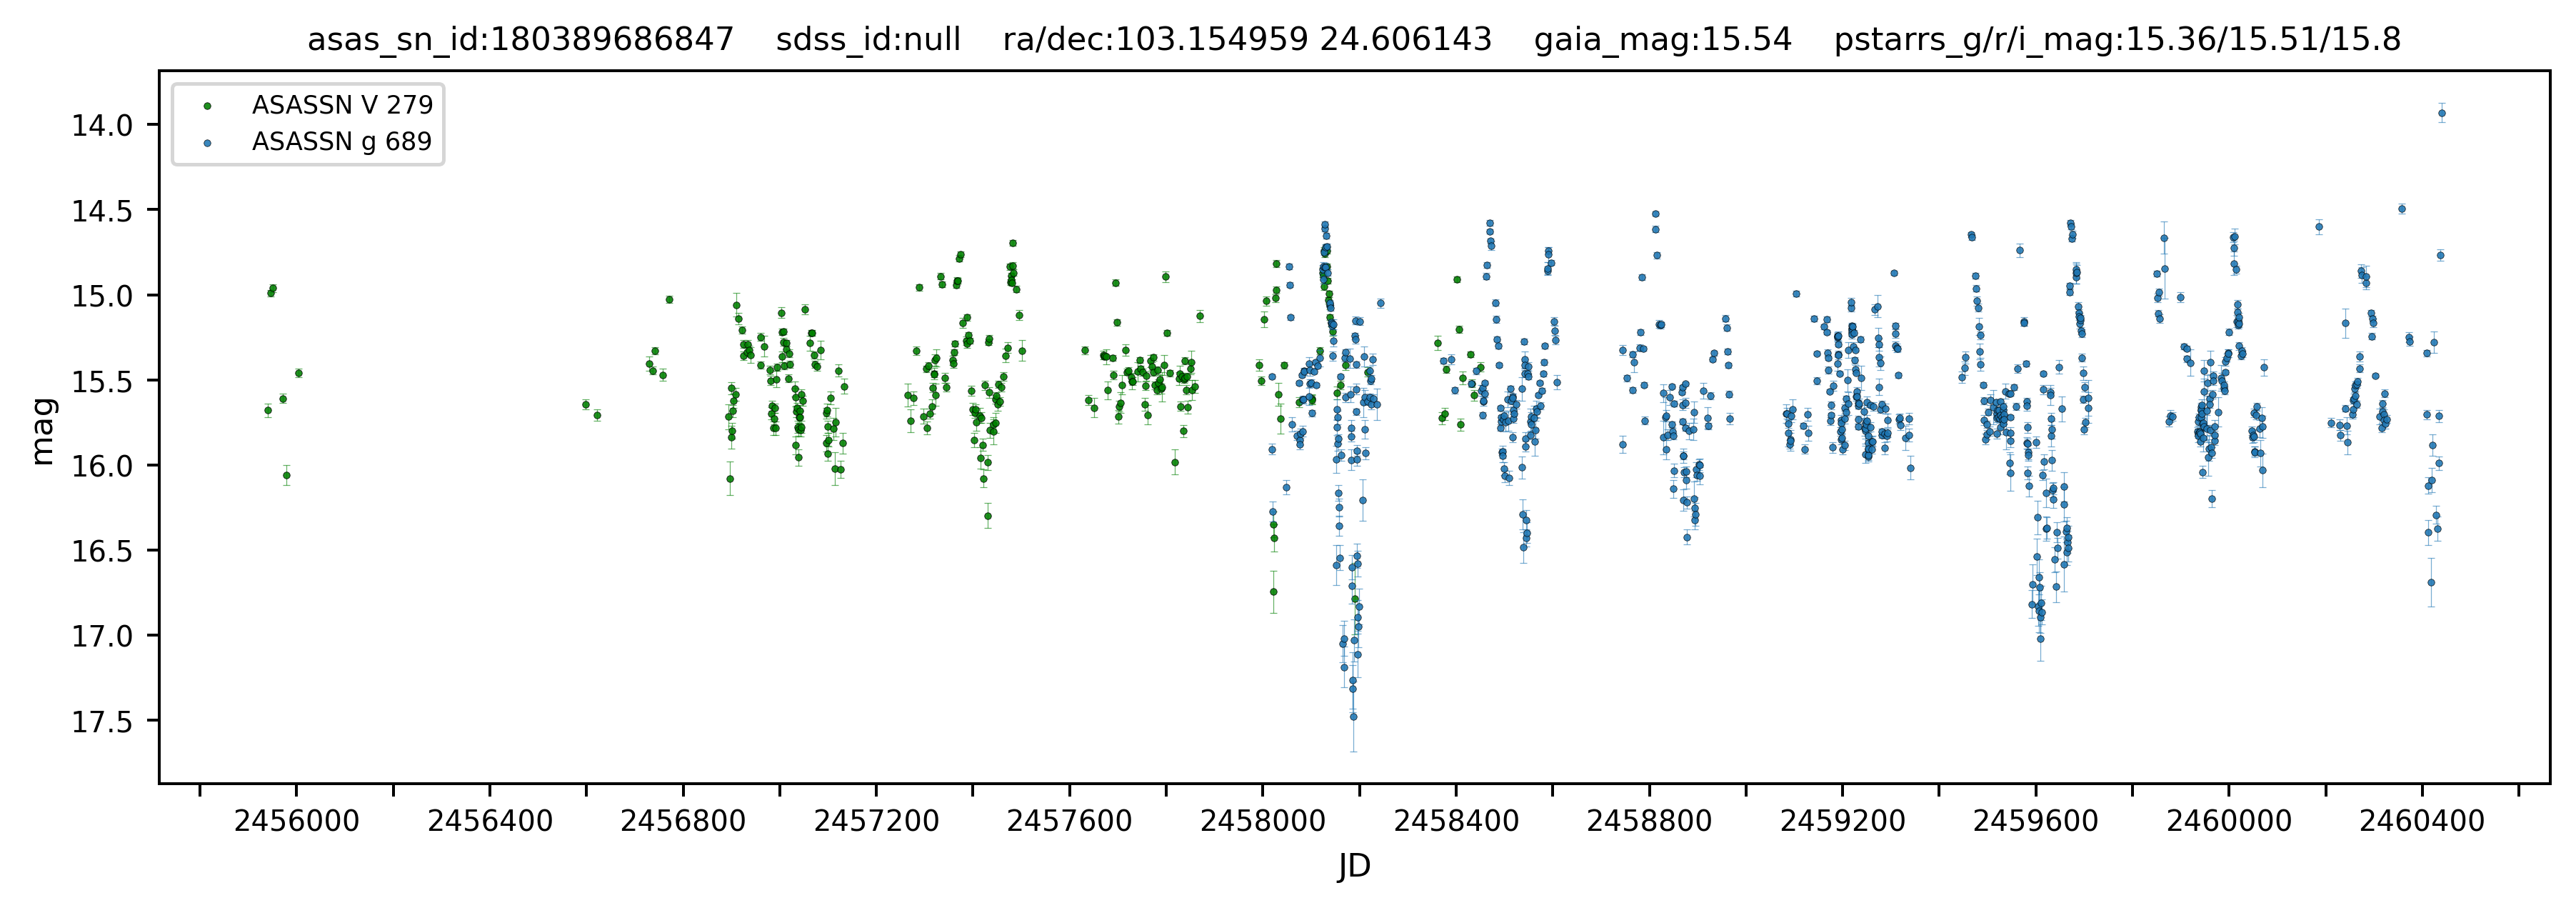

<Figure size 640x480 with 0 Axes>

In [17]:
def plot_lc(lc_path, save_path=None, ifshow=True):
    # 函数读取csv文件绘制光变曲线数据，并标注文字信息
    dataV, datag, header = output_data(lc_path)
    
    print('plot ASASSN data: V',len(dataV),'g',len(datag))
    valid = True
    # 计算asassn观测范围
    if len(dataV)==0 and len(datag)>0:
        max_jd = max(datag['jd'])
        min_jd = min(datag['jd'])
    elif len(datag)==0 and len(dataV)>0:
        max_jd = max(dataV['jd'])
        min_jd = min(dataV['jd'])
    elif len(dataV)>0 and len(datag)>0:
        max_jd = max(max(dataV['jd']),max(datag['jd']))
        min_jd = min(min(dataV['jd']),min(datag['jd']))
    else:
        valid = False
        
    if valid:
        jd_cover = max_jd - min_jd
        x_plot_range = np.arange(min_jd//200*200,max_jd+200,200)
        print('JD from ', round(min_jd,7),' to ', round(max_jd,7),'\tHJD_range:',round(jd_cover,2))

        ra = round(float(header["ra_deg"]),6)
        dec = round(float(header["dec_deg"]),6)
        gaiamag = round(float(header["gaia_mag"]),2)
        panstarrsg = round(float(header["pstarrs_g_mag"]),2)
        panstarrsr = round(float(header["pstarrs_r_mag"]),2)
        panstarrsi = round(float(header["pstarrs_i_mag"]),2)

        f = plt.figure(figsize=(12,3.6),dpi=360)
        V = plt.scatter(dataV['jd'], dataV['mag'], s=3.6, edgecolors='k',facecolor='g', marker='o',linewidths=0.17, alpha=0.88,zorder=3)
        plt.errorbar(dataV['jd'], dataV['mag'], yerr=dataV['mag_err'], 
                     linewidth=0, elinewidth=0.25, capsize=1, capthick=0.25, color='g', alpha=0.6,zorder=2)
        g = plt.scatter(datag['jd'], datag['mag'], s=3.6, edgecolors='k',facecolor='tab:blue', marker='o',linewidths=0.15, alpha=0.88,zorder=5)
        plt.errorbar(datag['jd'], datag['mag'], yerr=datag['mag_err'], 
                     linewidth=0, elinewidth=0.25, capsize=1, capthick=0.25, color='tab:blue', alpha=0.6,zorder=4)

        ax = plt.gca()
        ax.invert_yaxis()
        x_ticks = [str(int(np.round(iii,0))) for iii in x_plot_range]
        plt.xticks(x_plot_range, [x_ticks[jj] if jj%2==1 else '' for jj in range(len(x_ticks))],fontsize=8.)    
        plt.yticks(fontsize=8.)
        plt.xlabel('JD',fontsize=9)
        plt.ylabel('mag',fontsize=9)
        plt.title(f'asas_sn_id:{header["asas_sn_id"]}    sdss_id:{header["sdss_id"]}    '+\
                  f'ra/dec:{ra} {dec}    '+\
                  f'gaia_mag:{gaiamag}    '+\
                  f'pstarrs_g/r/i_mag:{panstarrsg}/{panstarrsr}/{panstarrsi}',
                  fontsize=9)
        plt.legend([f'ASASSN V {len(dataV)}',f'ASASSN g {len(datag)}'],fontsize=7,loc='upper left')
        if save_path is not None:
            plt.savefig(save_path, bbox_inches = 'tight', dpi=360)
        if ifshow:
            plt.show()
        plt.clf()
        plt.close(f)
    else:
        print('Can not plot ASASSN data.')

# 测试
#plot_lc('./Temp/J065238_ASAS/J065238_ASASSN_lc.csv', save_path='./Temp/asaslc_test1.png', ifshow=True)

In [6]:
# !pip install skypatrol

Looking in indexes: https://pypi.tuna.tsinghua.edu.cn/simple
